# Laboratorio 9 - Task 2: Proceso forward de difusión

En esta parte construimos el proceso forward de un modelo de difusión: la receta que toma una imagen limpia $x_0$ y la va ensuciando con ruido gaussiano durante $T=1000$ pasos hasta que no queda nada de ella. Verificamos numéricamente la forma cerrada del atajo, visualizamos cómo se destruye la imagen, medimos cuánta señal queda con el SNR y comparamos el calendario lineal contra uno de coseno diseñado por nosotros.

## Registro de uso de IA

- **Prompt utilizado:** `Ok podemos realizar el task 2, este es el roadmap establecido, guiate en la estructura de celda de codigo y celda de explicacion en md`
- **Por qué fue útil:** ordenó la Task 2 en pasos pequeños (calendario, atajo, verificación, visualización, SNR y calendario propio) y propuso visualizaciones para interpretar cada resultado.

## 0. Preparación

Fijamos la semilla 3045 para que cualquiera del equipo obtenga exactamente los mismos números y figuras. Todo se hace con tensores de PyTorch; no entrenamos nada en esta Task, así que la CPU alcanza.

In [1]:
from pathlib import Path
import math
import random

import matplotlib.pyplot as plt
import torch
from torchvision import datasets, transforms

SEED = 3045
T = 1000

ROOT = Path.cwd()
if ROOT.name == "notebooks":
    ROOT = ROOT.parent
DATA_DIR = ROOT / "data"
OUTPUT_DIR = ROOT / "outputs" / "task2"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)


def set_seed(seed: int = SEED) -> None:
    random.seed(seed)
    torch.manual_seed(seed)


set_seed()
print(f"Semilla: {SEED}")
print(f"Pasos de difusión T: {T}")
print(f"PyTorch: {torch.__version__}")

Semilla: 3045
Pasos de difusión T: 1000
PyTorch: 2.13.0+cpu


## 1. Task 2.1 - Datos en $[-1, 1]$

`ToTensor()` deja los píxeles en $[0,1]$ y `Normalize(0.5, 0.5)` aplica $x \mapsto (x-0.5)/0.5 = 2x-1$, que los lleva a $[-1,1]$. Este rango no es un capricho: el ruido $\varepsilon\sim\mathcal N(0,1)$ está centrado en 0, así que queremos que la imagen también lo esté. Al final del proceso forward la imagen debe parecerse a $\mathcal N(0, I)$, y eso solo encaja si los datos viven en una escala comparable.

In [2]:
transform = transforms.Compose([
    transforms.ToTensor(),
    transforms.Normalize((0.5,), (0.5,)),
])

train_set = datasets.FashionMNIST(
    DATA_DIR, train=True, download=True, transform=transform
)

labels = [
    "T-shirt/top", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot",
]

# Un tensor con 2,000 imágenes basta para revisar el rango y la distribución.
sample = torch.stack([train_set[i][0] for i in range(2000)])
print("forma de una imagen:", tuple(train_set[0][0].shape))
print(f"mínimo: {sample.min():.3f} | máximo: {sample.max():.3f}")
print(f"media: {sample.mean():.3f} | varianza: {sample.var():.3f}")
print(f"fracción de píxeles exactamente en -1 (fondo): {(sample == -1).float().mean():.3f}")

forma de una imagen: (1, 28, 28)
mínimo: -1.000 | máximo: 1.000
media: -0.432 | varianza: 0.500
fracción de píxeles exactamente en -1 (fondo): 0.507


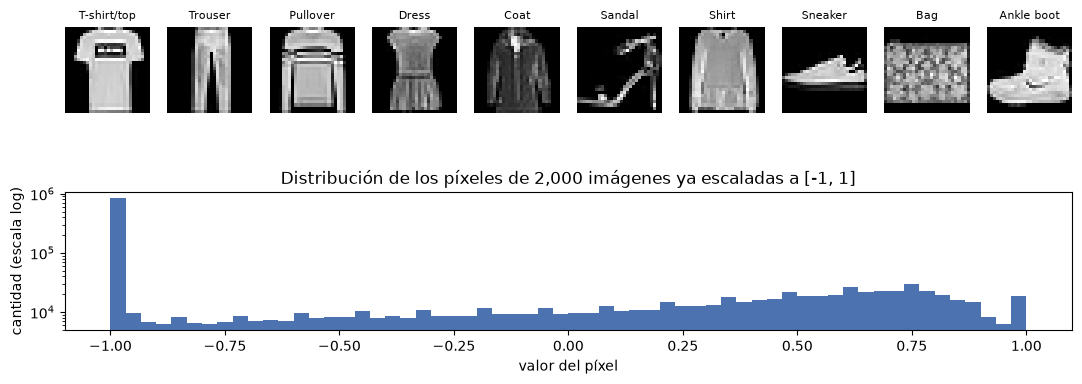

In [3]:
# Primera aparición de cada clase en el conjunto de entrenamiento.
first_of_class = {}
for i, target in enumerate(train_set.targets.tolist()):
    first_of_class.setdefault(target, i)
    if len(first_of_class) == 10:
        break

fig = plt.figure(figsize=(13, 4.2))
grid = fig.add_gridspec(2, 10, height_ratios=[1, 1.1], hspace=0.45)
for c in range(10):
    ax = fig.add_subplot(grid[0, c])
    ax.imshow(train_set[first_of_class[c]][0].squeeze(0), cmap="gray", vmin=-1, vmax=1)
    ax.set_title(labels[c], fontsize=8)
    ax.axis("off")

ax_hist = fig.add_subplot(grid[1, :])
ax_hist.hist(sample.flatten(), bins=60, range=(-1, 1), color="#4C72B0", log=True)
ax_hist.set_xlabel("valor del píxel")
ax_hist.set_ylabel("cantidad (escala log)")
ax_hist.set_title("Distribución de los píxeles de 2,000 imágenes ya escaladas a [-1, 1]")
plt.savefig(OUTPUT_DIR / "datos_escalados.png", dpi=180, bbox_inches="tight")
plt.show()

Los píxeles quedaron exactamente en $[-1,1]$. La media es $-0.432$ y no 0 porque cerca de la mitad de cada imagen (50.7 % de los píxeles) es fondo negro, que ahora vale $-1$; eso se ve en el pico gigante de la izquierda del histograma. La varianza de los datos es $0.500$. Este número lo retomamos en la Task 2.5c, porque la varianza de $x_t$ debe pasar de la de los datos ($\approx 0.5$) a la del ruido puro (1) a medida que avanza el proceso.

## 2. Task 2.1 - Calendario lineal de ruido

En cada paso $t$ el proceso forward agrega un poco de ruido según

$$q(x_t \mid x_{t-1}) = \mathcal N\!\left(\sqrt{\alpha_t}\,x_{t-1},\; \beta_t I\right), \qquad \alpha_t = 1-\beta_t.$$

$\beta_t$ es cuánto ruido nuevo entra en el paso $t$ y $\alpha_t$ es cuánto de la imagen anterior se conserva. El calendario lineal reparte $\beta_t$ en 1000 valores igualmente espaciados entre $\beta_1=10^{-4}$ y $\beta_T=0.02$. La cantidad que realmente importa es el producto acumulado

$$\bar\alpha_t = \prod_{s=1}^{t}\alpha_s,$$

que mide cuánto de la imagen original $x_0$ sobrevive después de $t$ pasos.

Los tensores de PyTorch empiezan en el índice 0, pero en las fórmulas $t$ va de 1 a $T$. Usamos la convención `tensor[t - 1]` para el paso $t$. Guardamos el calendario en `float64` porque $\bar\alpha_t$ llega a valores muy pequeños y más adelante tomamos logaritmos del SNR.

In [4]:
def linear_schedule(T: int = T, beta_start: float = 1e-4, beta_end: float = 0.02):
    betas = torch.linspace(beta_start, beta_end, T, dtype=torch.float64)
    alphas = 1.0 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars


betas, alphas, alpha_bars = linear_schedule()

print("formas:", tuple(betas.shape), tuple(alphas.shape), tuple(alpha_bars.shape))
print(f"{'t':>5} | {'beta_t':>9} | {'alpha_t':>9} | {'alpha_bar_t':>12}")
print("-" * 44)
for t in [1, 2, 10, 100, 250, 500, 750, 1000]:
    print(f"{t:5d} | {betas[t-1]:9.6f} | {alphas[t-1]:9.6f} | {alpha_bars[t-1]:12.6e}")

formas: (1000,) (1000,) (1000,)
    t |    beta_t |   alpha_t |  alpha_bar_t
--------------------------------------------
    1 |  0.000100 |  0.999900 | 9.999000e-01
    2 |  0.000120 |  0.999880 | 9.997801e-01
   10 |  0.000279 |  0.999721 | 9.981052e-01
  100 |  0.002072 |  0.997928 | 8.970181e-01
  250 |  0.005060 |  0.994940 | 5.240854e-01
  500 |  0.010040 |  0.989960 | 7.858724e-02
  750 |  0.015020 |  0.984980 | 3.350550e-03
 1000 |  0.020000 |  0.980000 | 4.035830e-05


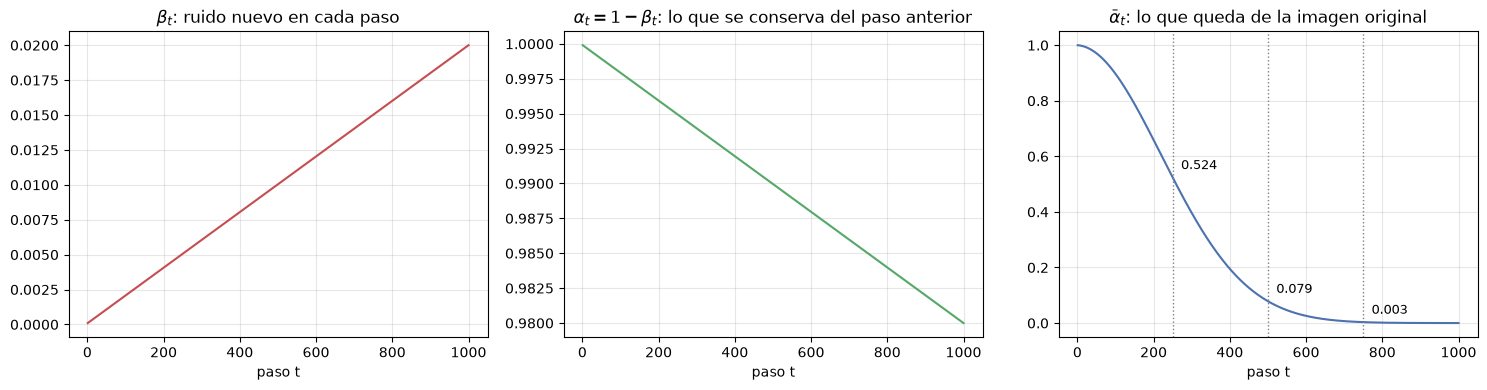

In [5]:
steps = torch.arange(1, T + 1)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
axes[0].plot(steps, betas, color="#C44E52")
axes[0].set_title(r"$\beta_t$: ruido nuevo en cada paso")
axes[1].plot(steps, alphas, color="#55A868")
axes[1].set_title(r"$\alpha_t = 1-\beta_t$: lo que se conserva del paso anterior")
axes[2].plot(steps, alpha_bars, color="#4C72B0")
axes[2].set_title(r"$\bar\alpha_t$: lo que queda de la imagen original")
for t_mark in [250, 500, 750]:
    axes[2].axvline(t_mark, color="gray", linestyle=":", linewidth=1)
    axes[2].annotate(f"{alpha_bars[t_mark-1]:.3f}", (t_mark, alpha_bars[t_mark-1].item()),
                     textcoords="offset points", xytext=(6, 6), fontsize=9)
for ax in axes:
    ax.set_xlabel("paso t")
    ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "calendario_lineal.png", dpi=180, bbox_inches="tight")
plt.show()

Obtuvimos tres tensores de 1000 valores. $\beta_t$ y $\alpha_t$ son rectas, pero $\bar\alpha_t$ no lo es: aunque cada $\alpha_t$ está siempre entre 0.98 y 0.9999, multiplicar mil números apenas menores que 1 termina en casi cero. Al final del calendario queda $\bar\alpha_T = 4.04\times10^{-5}$ de la imagen original.

La curva de $\bar\alpha_t$ cae despacio al principio ($\bar\alpha_{100}=0.897$) porque los primeros $\beta_t$ son diminutos, baja rápido en el tramo medio ($0.524$ en $t=250$ y $0.079$ en $t=500$) y para $t=750$ ya solo queda $0.003$. Eso sugiere que el último cuarto de los pasos trabaja sobre algo que ya es casi puro ruido; lo medimos con el SNR en la Task 2.3 y lo atacamos con el calendario de coseno en la 2.4.

## 3. Task 2.1 - El atajo en forma cerrada

Aplicar el ruido paso por paso para llegar a $t=700$ exigiría 700 operaciones por imagen. La forma cerrada permite saltar directamente de $x_0$ a cualquier $x_t$ con un solo ruido:

$$x_t = \sqrt{\bar\alpha_t}\,x_0 + \sqrt{1-\bar\alpha_t}\,\varepsilon, \qquad \varepsilon\sim\mathcal N(0, I).$$

El primer término es la **señal** (la imagen original encogida) y el segundo es el **ruido** acumulado. Los coeficientes cumplen $(\sqrt{\bar\alpha_t})^2 + (\sqrt{1-\bar\alpha_t})^2 = 1$, así que conforme la imagen pierde peso, el ruido gana exactamente lo que ella pierde.

La función `q_sample` acepta un `t` entero o un tensor con un `t` distinto por imagen del lote, que es lo que necesitaremos en la Task 3 para entrenar la U-Net. Devuelve también el ruido $\varepsilon$ usado, porque ese será el objetivo que la red debe predecir.

In [6]:
def q_sample(x0, t, alpha_bars, noise=None, generator=None):
    """Salta de x_0 a x_t con x_t = sqrt(a_bar_t) x_0 + sqrt(1 - a_bar_t) eps.

    t va de 1 a T. Puede ser un entero o un tensor de forma (B,).
    """
    if noise is None:
        noise = torch.randn(x0.shape, generator=generator, dtype=x0.dtype, device=x0.device)
    t = torch.as_tensor(t, device=alpha_bars.device)
    a_bar = alpha_bars[t - 1].to(dtype=x0.dtype, device=x0.device)
    # Una forma (B, 1, 1, 1) para que cada imagen use su propio a_bar_t.
    a_bar = a_bar.view(-1, *([1] * (x0.dim() - 1)))
    x_t = a_bar.sqrt() * x0 + (1 - a_bar).sqrt() * noise
    return x_t, noise


# Pruebas rápidas de la función.
x0 = train_set[first_of_class[0]][0].unsqueeze(0)  # (1, 1, 28, 28)
g = torch.Generator().manual_seed(SEED)

x_1, _ = q_sample(x0, 1, alpha_bars, generator=g)
x_T, eps_T = q_sample(x0, T, alpha_bars, generator=g)
print(f"t=1:    |x_1 - x_0| máximo = {(x_1 - x0).abs().max():.4f}  (casi la imagen limpia)")
print(f"t=1000: |x_T - eps| máximo = {(x_T - eps_T).abs().max():.4f}  (casi ruido puro)")

batch = torch.stack([train_set[i][0] for i in range(4)])
t_batch = torch.tensor([1, 250, 500, 1000])
x_t_batch, eps_batch = q_sample(batch, t_batch, alpha_bars, generator=g)
print("lote con un t distinto por imagen:", tuple(x_t_batch.shape), "con t =", t_batch.tolist())

t=1:    |x_1 - x_0| máximo = 0.0332  (casi la imagen limpia)
t=1000: |x_T - eps| máximo = 0.0064  (casi ruido puro)
lote con un t distinto por imagen: (4, 1, 28, 28) con t = [1, 250, 500, 1000]


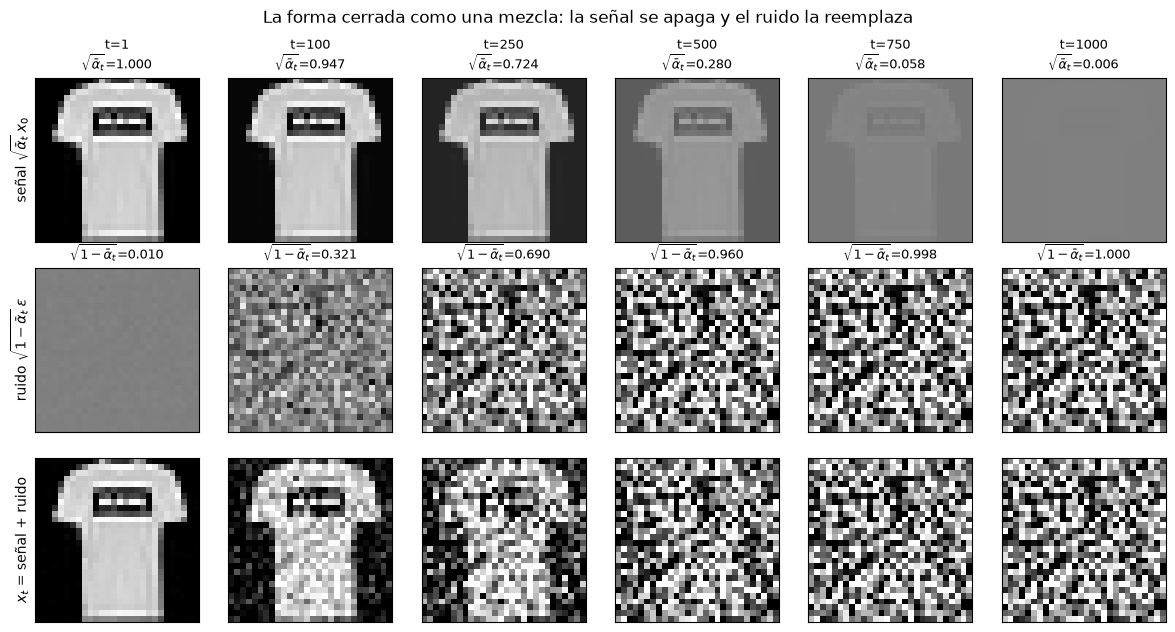

In [7]:
# Descomponemos x_t en sus dos sumandos para la misma camiseta y el mismo ruido.
t_show = [1, 100, 250, 500, 750, 1000]
eps = torch.randn(x0.shape, generator=torch.Generator().manual_seed(SEED))

fig, axes = plt.subplots(3, len(t_show), figsize=(12, 6.4))
row_names = [r"señal $\sqrt{\bar\alpha_t}\,x_0$", r"ruido $\sqrt{1-\bar\alpha_t}\,\varepsilon$", r"$x_t$ = señal + ruido"]
for col, t in enumerate(t_show):
    a_bar = alpha_bars[t - 1].float()
    signal = a_bar.sqrt() * x0
    noise_part = (1 - a_bar).sqrt() * eps
    x_t, _ = q_sample(x0, t, alpha_bars, noise=eps)
    for row, img in enumerate([signal, noise_part, x_t]):
        ax = axes[row, col]
        ax.imshow(img.squeeze(), cmap="gray", vmin=-1, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if col == 0:
            ax.set_ylabel(row_names[row], fontsize=10)
    axes[0, col].set_title(f"t={t}\n" + rf"$\sqrt{{\bar\alpha_t}}$={a_bar.sqrt():.3f}", fontsize=9)
    axes[1, col].set_title(rf"$\sqrt{{1-\bar\alpha_t}}$={(1 - a_bar).sqrt():.3f}", fontsize=9)
fig.suptitle("La forma cerrada como una mezcla: la señal se apaga y el ruido la reemplaza")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "atajo_descomposicion.png", dpi=180, bbox_inches="tight")
plt.show()

Las pruebas confirman los dos extremos: en $t=1$ el cambio máximo de un píxel es apenas $0.033$, así que $x_1$ es prácticamente la imagen limpia, y en $t=1000$ la diferencia entre $x_T$ y el ruido es como mucho $0.006$, así que $x_T$ es prácticamente ruido puro. La función también funciona con un lote donde cada imagen tiene su propio $t$.

La figura muestra la fórmula como una mezcla de dos ingredientes. La fila de arriba es la camiseta multiplicada por $\sqrt{\bar\alpha_t}$: no se borra, se va apagando hacia el gris (el 0). La fila del medio es el mismo ruido multiplicado por $\sqrt{1-\bar\alpha_t}$, que va subiendo de volumen. La fila de abajo es su suma. En $t=500$ la camiseta todavía se reconoce en la fila de la señal, pero en $x_t$ ya no, porque su peso ($0.280$) es mucho menor que el del ruido ($0.960$). Las imágenes se muestran recortadas a $[-1,1]$ para usar la misma escala de grises en todas.

## 4. Task 2.2 - Verificación numérica del atajo

El atajo dice que, después de $t$ pasos, $x_t \mid x_0 \sim \mathcal N\!\left(\sqrt{\bar\alpha_t}\,x_0,\;(1-\bar\alpha_t) I\right)$. Para comprobarlo sin usar la fórmula, hacemos el camino largo: tomamos **5,000 copias** de la misma imagen y a cada una le aplicamos 300 veces el paso individual

$$x_t = \sqrt{\alpha_t}\,x_{t-1} + \sqrt{\beta_t}\,\varepsilon_t,$$

con un ruido nuevo e independiente en cada paso. Luego medimos, píxel por píxel, la media y la varianza de las 5,000 copias y las comparamos con $\sqrt{\bar\alpha_{300}}\,x_0$ y $1-\bar\alpha_{300}$.

La razón de fondo es que **sumar ruidos gaussianos independientes da otro ruido gaussiano**, con varianza igual a la suma de las varianzas. Por eso los 300 ruidos pequeños se pueden reemplazar por uno solo.

Como trabajamos con muestras finitas, la media empírica nunca será idéntica a la teórica. La referencia para decidir si el error es "pequeño" es el **error estándar**: para la media de un píxel es $\sqrt{(1-\bar\alpha_t)/N}$, y para la varianza promediada sobre los 784 píxeles es $(1-\bar\alpha_t)\sqrt{2/(N-1)}/\sqrt{784}$. Con 784 píxeles, el error máximo de la media debería caer alrededor de 3 o 4 errores estándar.

In [8]:
N_COPIES = 5_000
T_CHECK = 300

x0 = train_set[first_of_class[0]][0].double()  # (1, 28, 28), la misma camiseta de antes
g = torch.Generator().manual_seed(SEED)

x = x0.expand(N_COPIES, -1, -1, -1).clone()
history = {"var_mean": [], "pixel_bright": [], "pixel_dark": []}
bright = (0, 14, 14)  # un píxel de la tela
dark = (0, 2, 2)      # un píxel del fondo

for t in range(1, T_CHECK + 1):
    noise = torch.randn(x.shape, generator=g, dtype=torch.float64)
    x = alphas[t - 1].sqrt() * x + betas[t - 1].sqrt() * noise
    history["var_mean"].append(x.var(dim=0).mean().item())
    history["pixel_bright"].append(x[(slice(None),) + bright].mean().item())
    history["pixel_dark"].append(x[(slice(None),) + dark].mean().item())

a_bar = alpha_bars[T_CHECK - 1]
mean_theory = a_bar.sqrt() * x0
var_theory = 1 - a_bar

mean_emp = x.mean(dim=0)
var_emp = x.var(dim=0)

max_mean_err = (mean_emp - mean_theory).abs().max().item()
se_mean = math.sqrt(var_theory / N_COPIES)
var_avg = var_emp.mean().item()
se_var = var_theory.item() * math.sqrt(2 / (N_COPIES - 1)) / math.sqrt(x0.numel())

print(f"t = {T_CHECK}, alpha_bar_t = {a_bar:.6f}")
print(f"media:    error máximo en 784 píxeles = {max_mean_err:.5f} | error estándar = {se_mean:.5f} "
      f"| razón = {max_mean_err / se_mean:.2f}")
print(f"varianza: promedio empírico = {var_avg:.5f} | teórica = {var_theory:.5f} "
      f"| diferencia = {abs(var_avg - var_theory):.5f} | error estándar = {se_var:.5f} "
      f"| razón = {abs(var_avg - var_theory) / se_var:.2f}")

t = 300, alpha_bar_t = 0.396420
media:    error máximo en 784 píxeles = 0.04463 | error estándar = 0.01099 | razón = 4.06
varianza: promedio empírico = 0.60309 | teórica = 0.60358 | diferencia = 0.00049 | error estándar = 0.00043 | razón = 1.13


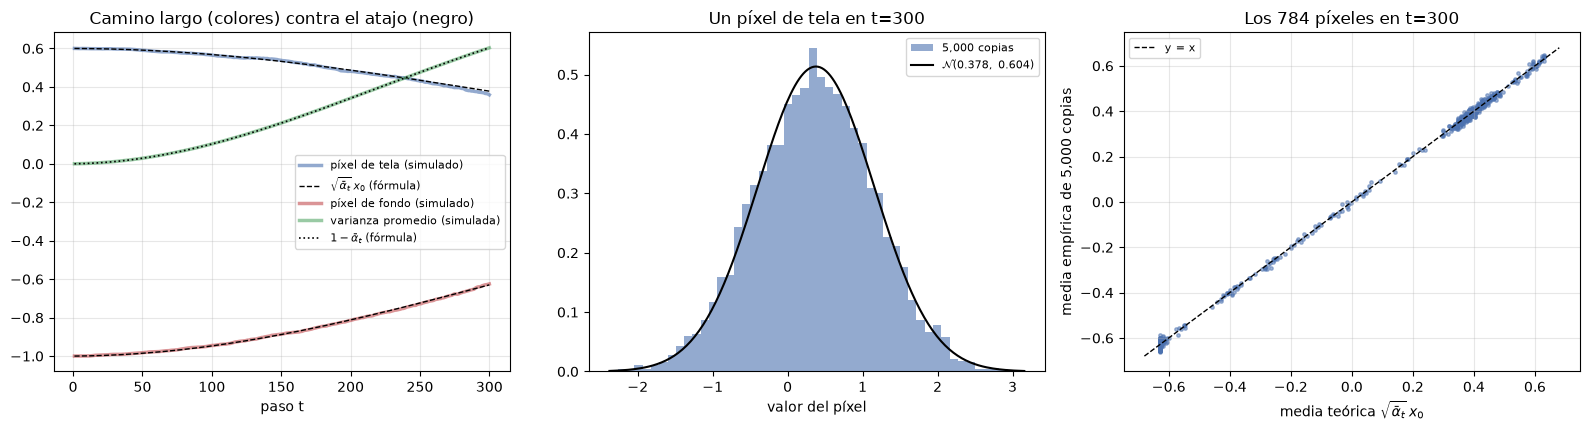

In [9]:
t_axis = torch.arange(1, T_CHECK + 1)
ab = alpha_bars[:T_CHECK]

fig, axes = plt.subplots(1, 3, figsize=(16, 4.4))

ax = axes[0]
ax.plot(t_axis, history["pixel_bright"], color="#4C72B0", linewidth=2.5, alpha=0.6, label="píxel de tela (simulado)")
ax.plot(t_axis, ab.sqrt() * x0[bright], "k--", linewidth=1, label=r"$\sqrt{\bar\alpha_t}\,x_0$ (fórmula)")
ax.plot(t_axis, history["pixel_dark"], color="#C44E52", linewidth=2.5, alpha=0.6, label="píxel de fondo (simulado)")
ax.plot(t_axis, ab.sqrt() * x0[dark], "k--", linewidth=1)
ax.plot(t_axis, history["var_mean"], color="#55A868", linewidth=2.5, alpha=0.6, label="varianza promedio (simulada)")
ax.plot(t_axis, 1 - ab, "k:", linewidth=1.2, label=r"$1-\bar\alpha_t$ (fórmula)")
ax.set_xlabel("paso t")
ax.set_title("Camino largo (colores) contra el atajo (negro)")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

ax = axes[1]
values = x[(slice(None),) + bright]
ax.hist(values, bins=50, density=True, color="#4C72B0", alpha=0.6, label="5,000 copias")
grid_x = torch.linspace(values.min(), values.max(), 200, dtype=torch.float64)
mu, var = mean_theory[bright], var_theory
density = torch.exp(-(grid_x - mu) ** 2 / (2 * var)) / torch.sqrt(2 * math.pi * var)
ax.plot(grid_x, density, "k", linewidth=1.5, label=rf"$\mathcal{{N}}({mu:.3f},\ {var:.3f})$")
ax.set_title(f"Un píxel de tela en t={T_CHECK}")
ax.set_xlabel("valor del píxel")
ax.legend(fontsize=8)

ax = axes[2]
ax.scatter(mean_theory.flatten(), mean_emp.flatten(), s=6, alpha=0.5, color="#4C72B0")
lims = [mean_theory.min().item() - 0.05, mean_theory.max().item() + 0.05]
ax.plot(lims, lims, "k--", linewidth=1, label="y = x")
ax.set_xlabel(r"media teórica $\sqrt{\bar\alpha_t}\,x_0$")
ax.set_ylabel("media empírica de 5,000 copias")
ax.set_title(f"Los 784 píxeles en t={T_CHECK}")
ax.legend(fontsize=8)
ax.grid(alpha=0.3)

plt.tight_layout()
plt.savefig(OUTPUT_DIR / "verificacion_atajo.png", dpi=180, bbox_inches="tight")
plt.show()

En $t=300$ la fórmula predice $\bar\alpha_{300}=0.3964$, es decir, una varianza de $1-\bar\alpha_{300}=0.6036$.

| Cantidad | Simulado (300 pasos) | Fórmula | Diferencia | Error estándar | Diferencia / error estándar |
|---|---|---|---|---|---|
| Media, error máximo en los 784 píxeles | | | 0.0446 | 0.0110 | 4.06 |
| Varianza promedio | 0.6031 | 0.6036 | 0.0005 | 0.0004 | 1.13 |

La varianza promedio quedó a solo 1.13 errores estándar de la teórica, que es lo que esperaríamos por puro azar. Para la media reportamos el **peor** de los 784 píxeles, y al tomar el máximo de tantos valores lo normal es que alguno se aleje más: con 784 píxeles independientes, la mediana de ese máximo es 3.3 errores estándar y la probabilidad de ver 4.06 o más es de 3.8 %. El resultado está algo por encima de lo típico, pero es compatible con ruido de muestreo; no indica un error sistemático.

La figura lo confirma de tres formas. A la izquierda, las curvas simuladas paso por paso se montan sobre las de la fórmula durante los 300 pasos, tanto para un píxel de tela como para uno de fondo y para la varianza. En el centro, las 5,000 copias de un píxel forman exactamente la campana $\mathcal N(0.378,\,0.604)$ que predice el atajo. A la derecha, los 784 píxeles caen sobre la recta $y=x$. Concluimos que aplicar 300 ruidos pequeños uno tras otro es equivalente a aplicar un solo ruido con varianza $1-\bar\alpha_t$, porque la suma de gaussianas independientes es otra gaussiana.

## 5. Task 2.3a - Cómo se destruye la imagen

Usamos `q_sample` para ver tres clases con formas muy distintas (Trouser, Sneaker y Bag) en $t\in\{1, 50, 100, 250, 500, 750, 1000\}$. Cada fila usa **un mismo ruido** $\varepsilon$ en todas las columnas; así lo único que cambia de izquierda a derecha es la proporción entre señal y ruido, y no el patrón de manchas.

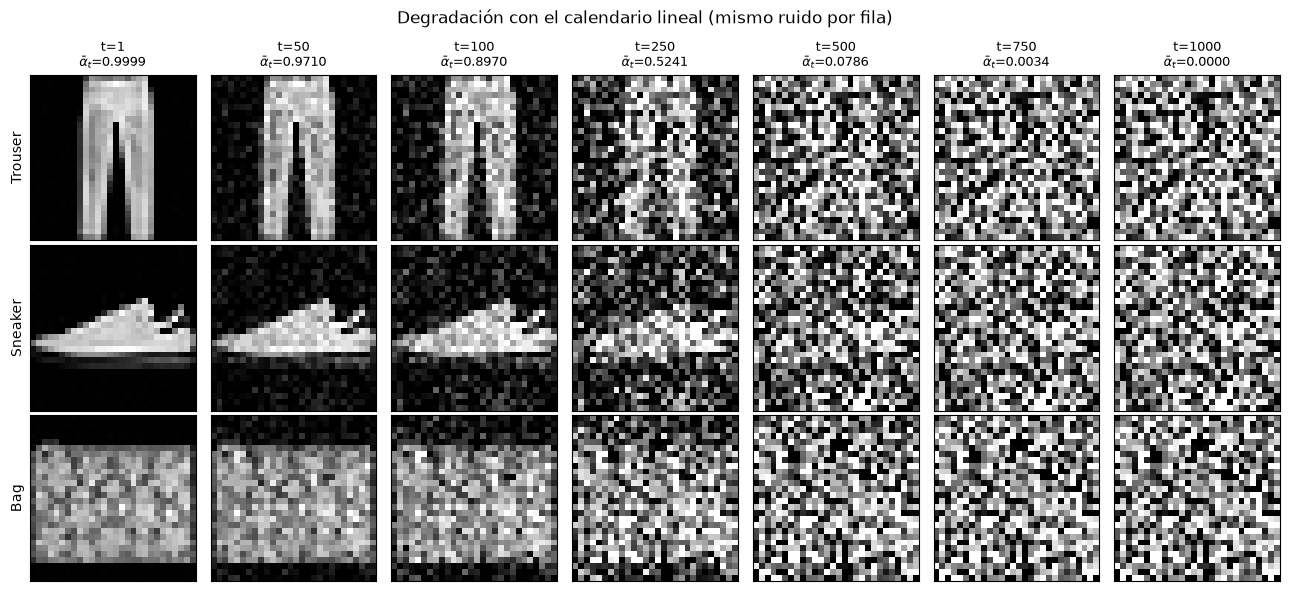

In [10]:
T_GRID = [1, 50, 100, 250, 500, 750, 1000]
CLASSES_GRID = [1, 7, 8]  # Trouser, Sneaker, Bag

g = torch.Generator().manual_seed(SEED)
fig, axes = plt.subplots(len(CLASSES_GRID), len(T_GRID), figsize=(13, 6))
for row, c in enumerate(CLASSES_GRID):
    x0_c = train_set[first_of_class[c]][0].unsqueeze(0)
    eps_c = torch.randn(x0_c.shape, generator=g)
    for col, t in enumerate(T_GRID):
        x_t, _ = q_sample(x0_c, t, alpha_bars, noise=eps_c)
        ax = axes[row, col]
        ax.imshow(x_t.squeeze(), cmap="gray", vmin=-1, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        if row == 0:
            ax.set_title(f"t={t}\n" + rf"$\bar\alpha_t$={alpha_bars[t-1]:.4f}", fontsize=9)
        if col == 0:
            ax.set_ylabel(labels[c], fontsize=10)
fig.suptitle("Degradación con el calendario lineal (mismo ruido por fila)")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "degradacion_3x7.png", dpi=180, bbox_inches="tight")
plt.show()

Para ver lo mismo de forma global, repetimos el histograma de píxeles del inicio, ahora sobre las 2,000 imágenes ya ensuciadas en cada $t$. La curva negra es la campana $\mathcal N(0,1)$ del ruido puro, a la que el proceso debería llegar.

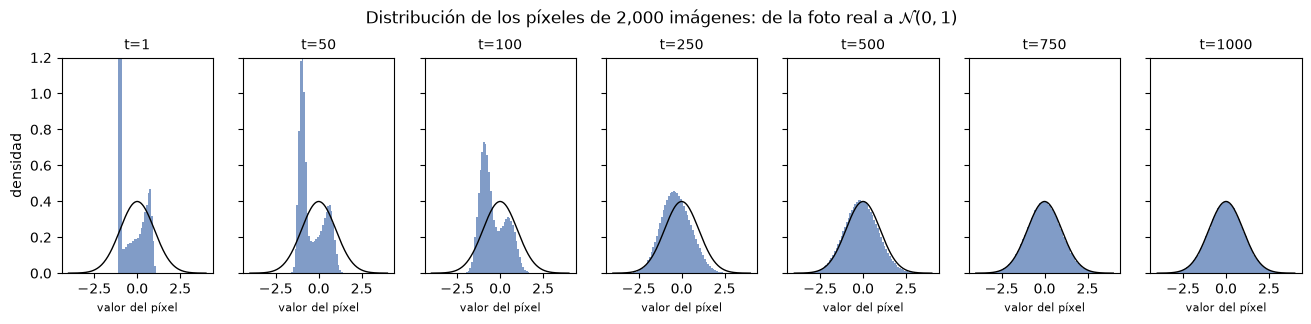

In [11]:
g = torch.Generator().manual_seed(SEED)
eps_sample = torch.randn(sample.shape, generator=g)
grid_x = torch.linspace(-4, 4, 200)
standard_normal = torch.exp(-grid_x ** 2 / 2) / math.sqrt(2 * math.pi)

fig, axes = plt.subplots(1, len(T_GRID), figsize=(16, 2.8), sharey=True)
for ax, t in zip(axes, T_GRID):
    x_t, _ = q_sample(sample, torch.full((len(sample),), t), alpha_bars, noise=eps_sample)
    ax.hist(x_t.flatten(), bins=80, range=(-4, 4), density=True, color="#4C72B0", alpha=0.7)
    ax.plot(grid_x, standard_normal, "k", linewidth=1)
    ax.set_title(f"t={t}", fontsize=10)
    ax.set_xlabel("valor del píxel", fontsize=8)
    ax.set_ylim(0, 1.2)
axes[0].set_ylabel("densidad")
fig.suptitle(r"Distribución de los píxeles de 2,000 imágenes: de la foto real a $\mathcal{N}(0,1)$", y=1.05)
plt.savefig(OUTPUT_DIR / "histogramas_degradacion.png", dpi=180, bbox_inches="tight")
plt.show()

En la cuadrícula, hasta $t=100$ ($\bar\alpha_t\approx0.90$) las tres prendas siguen perfectamente reconocibles: el fondo negro se llena de granitos, pero la forma está intacta. En $t=250$ ($\bar\alpha_t=0.52$) todavía se adivina la silueta del Sneaker y las dos piernas del Trouser; el Bag es el que más sufre, porque su textura interna se confunde con el ruido. Desde $t=500$ ($\bar\alpha_t=0.079$) ya no distinguimos ninguna prenda a simple vista, y las columnas $t=750$ y $t=1000$ se ven prácticamente iguales entre sí. Es decir, toda la información visual se pierde en la primera mitad del calendario.

Los histogramas cuentan la misma historia para las 2,000 imágenes juntas. En $t=1$ tenemos la distribución de las fotos: el pico del fondo en $-1$ (recortado en el gráfico porque es mucho más alto) y la tela entre 0.5 y 0.8. Con el tiempo el pico se ensancha, se corre hacia 0 y se funde con el bloque de la tela; en $t=250$ ya parece una campana, aunque desplazada a la izquierda, y desde $t=500$ coincide casi por completo con $\mathcal N(0,1)$. Al final, $x_T$ es indistinguible del ruido puro, que es justo el punto de partida que usará el muestreo en la Task 3.

## 6. Task 2.3b - $\bar\alpha_t$ y la relación señal a ruido

En $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$, la potencia de la señal es $\bar\alpha_t$ y la del ruido es $1-\bar\alpha_t$ (los coeficientes al cuadrado). Su cociente es la relación señal a ruido:

$$\text{SNR}(t)=\frac{\bar\alpha_t}{1-\bar\alpha_t}.$$

Si $\text{SNR}>1$ en $x_t$ hay más imagen que ruido; si $\text{SNR}<1$, domina el ruido. Como el SNR va desde casi $10^4$ hasta $10^{-5}$, lo graficamos en escala logarítmica: en escala normal toda la curva después de los primeros pasos se vería pegada al cero.

In [12]:
def snr(alpha_bars):
    return alpha_bars / (1 - alpha_bars)


snr_linear = snr(alpha_bars)

print(f"{'t':>5} | {'alpha_bar_t':>12} | {'SNR(t)':>12}")
print("-" * 35)
for t in [1, 50, 100, 250, 500, 750, 1000]:
    print(f"{t:5d} | {alpha_bars[t-1]:12.6f} | {snr_linear[t-1]:12.4e}")

    t |  alpha_bar_t |       SNR(t)
-----------------------------------
    1 |     0.999900 |   9.9990e+03
   50 |     0.971016 |   3.3501e+01
  100 |     0.897018 |   8.7104e+00
  250 |     0.524085 |   1.1012e+00
  500 |     0.078587 |   8.5290e-02
  750 |     0.003351 |   3.3618e-03
 1000 |     0.000040 |   4.0360e-05


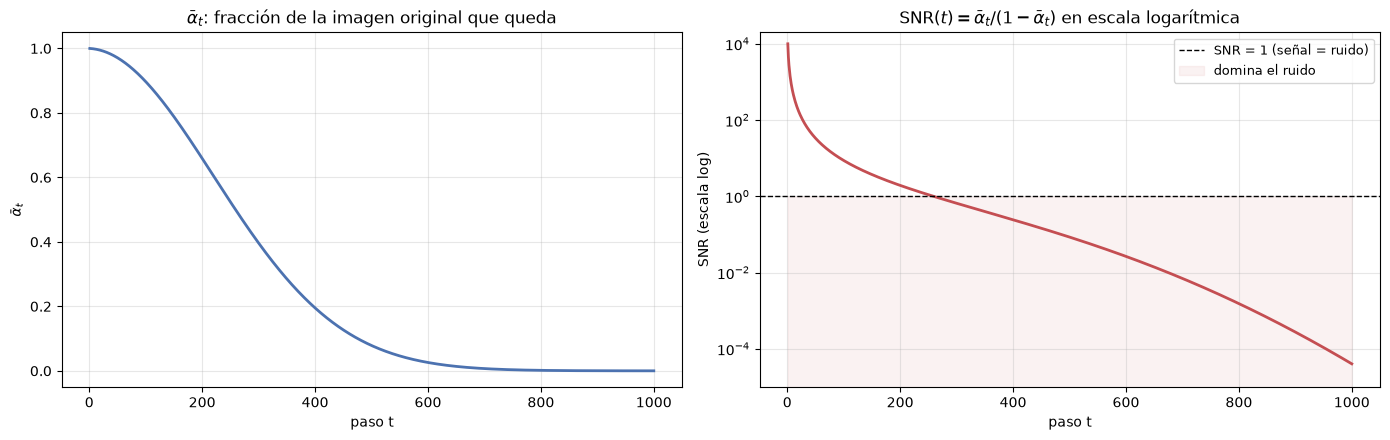

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(14, 4.5))

axes[0].plot(steps, alpha_bars, color="#4C72B0", linewidth=2)
axes[0].set_title(r"$\bar\alpha_t$: fracción de la imagen original que queda")
axes[0].set_ylabel(r"$\bar\alpha_t$")

axes[1].semilogy(steps, snr_linear, color="#C44E52", linewidth=2)
axes[1].axhline(1, color="black", linestyle="--", linewidth=1, label="SNR = 1 (señal = ruido)")
axes[1].fill_between(steps, 1e-6, 1, color="#C44E52", alpha=0.07, label="domina el ruido")
axes[1].set_ylim(1e-5, 2e4)
axes[1].set_title(r"SNR$(t)=\bar\alpha_t/(1-\bar\alpha_t)$ en escala logarítmica")
axes[1].set_ylabel("SNR (escala log)")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel("paso t")
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "alpha_bar_y_snr_lineal.png", dpi=180, bbox_inches="tight")
plt.show()

La gráfica de $\bar\alpha_t$ muestra la caída en escala lineal: desde $t\approx600$ la curva está pegada al cero y ya no se distingue nada. La del SNR, en escala logarítmica, sí permite ver qué pasa en esa zona. El SNR baja de $\approx10^4$ en $t=1$ a $33.5$ en $t=50$ y $8.7$ en $t=100$: los primeros pasos destruyen rápido los detalles finos, aunque la imagen siga reconociéndose. Cruza la línea $\text{SNR}=1$ poco después de $t=250$ (donde vale $1.10$), y a partir de ahí el ruido domina. Luego sigue bajando de forma casi recta en escala log hasta $4\times10^{-5}$ en $t=1000$.

La conclusión es que con el calendario lineal **cerca de tres cuartas partes de los pasos ocurren con más ruido que señal**, y en los últimos cientos el SNR es tan bajo que $x_t$ es prácticamente ruido puro. En la Task 2.3c ubicamos exactamente esos puntos de cruce.

## 7. Task 2.3c - Dos puntos de referencia

Buscamos dos umbrales sobre el calendario lineal:

- El primer $t$ con $\text{SNR}(t)<1$, que es cuando el ruido empieza a pesar más que la imagen. Como $\text{SNR}<1 \iff \bar\alpha_t<1-\bar\alpha_t \iff \bar\alpha_t<0.5$, equivale al primer paso en que queda menos de la mitad de la imagen.
- El primer $t$ con $\bar\alpha_t<0.01$, cuando queda menos del 1 % de la imagen original.

Como $\bar\alpha_t$ siempre decrece, basta con encontrar el primer índice que cumple cada condición y sumarle 1 para pasar de índice de PyTorch a paso $t$.

In [14]:
def first_step_where(condition: torch.Tensor) -> int:
    """Primer t (de 1 a T) en que se cumple la condición."""
    return int(torch.nonzero(condition)[0].item()) + 1


t_snr_below_1 = first_step_where(snr_linear < 1)
t_ab_below_001 = first_step_where(alpha_bars < 0.01)

for name, t in [("SNR < 1", t_snr_below_1), ("alpha_bar < 0.01", t_ab_below_001)]:
    print(f"Primer t con {name}: t = {t}")
    for s in [t - 1, t]:
        print(f"    t = {s}: alpha_bar = {alpha_bars[s-1]:.6f} | SNR = {snr_linear[s-1]:.6f}")
print(f"Pasos que quedan después de alpha_bar < 0.01: {T - t_ab_below_001 + 1} de {T}")

Primer t con SNR < 1: t = 260
    t = 259: alpha_bar = 0.500245 | SNR = 1.000979
    t = 260: alpha_bar = 0.497614 | SNR = 0.990501
Primer t con alpha_bar < 0.01: t = 674
    t = 673: alpha_bar = 0.010128 | SNR = 0.010232
    t = 674: alpha_bar = 0.009991 | SNR = 0.010092
Pasos que quedan después de alpha_bar < 0.01: 327 de 1000


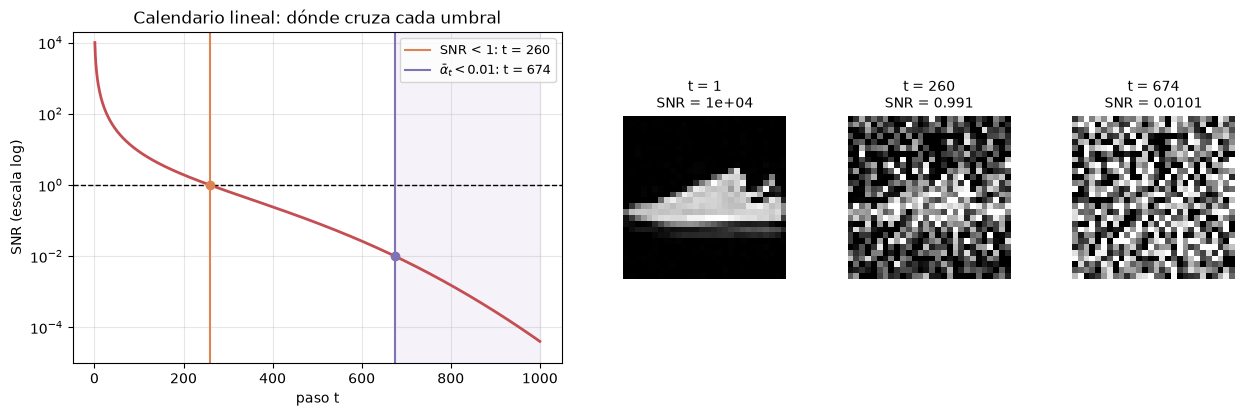

In [15]:
fig = plt.figure(figsize=(15, 4.3))
grid = fig.add_gridspec(1, 4, width_ratios=[3, 1, 1, 1], wspace=0.25)

ax = fig.add_subplot(grid[0])
ax.semilogy(steps, snr_linear, color="#C44E52", linewidth=2)
ax.axhline(1, color="black", linestyle="--", linewidth=1)
marks = [(t_snr_below_1, "#DD8452", "SNR < 1"), (t_ab_below_001, "#8172B3", r"$\bar\alpha_t<0.01$")]
for t, color, name in marks:
    ax.axvline(t, color=color, linewidth=1.5, label=f"{name}: t = {t}")
    ax.scatter([t], [snr_linear[t - 1].item()], color=color, zorder=3)
ax.axvspan(t_ab_below_001, T, color="#8172B3", alpha=0.08)
ax.set_ylim(1e-5, 2e4)
ax.set_xlabel("paso t")
ax.set_ylabel("SNR (escala log)")
ax.set_title("Calendario lineal: dónde cruza cada umbral")
ax.legend(fontsize=9)
ax.grid(alpha=0.3, which="both")

x0_sneaker = train_set[first_of_class[7]][0].unsqueeze(0)
eps_sneaker = torch.randn(x0_sneaker.shape, generator=torch.Generator().manual_seed(SEED))
for k, t in enumerate([1, t_snr_below_1, t_ab_below_001]):
    x_t, _ = q_sample(x0_sneaker, t, alpha_bars, noise=eps_sneaker)
    ax_img = fig.add_subplot(grid[k + 1])
    ax_img.imshow(x_t.squeeze(), cmap="gray", vmin=-1, vmax=1)
    ax_img.set_title(f"t = {t}\nSNR = {snr_linear[t-1]:.3g}", fontsize=10)
    ax_img.axis("off")

plt.savefig(OUTPUT_DIR / "umbrales_snr_lineal.png", dpi=180, bbox_inches="tight")
plt.show()

| Umbral | Primer $t$ | $\bar\alpha_t$ en ese paso | SNR en ese paso |
|---|---|---|---|
| $\text{SNR}<1$ | **260** | 0.4976 | 0.9905 |
| $\bar\alpha_t<0.01$ | **674** | 0.00999 | 0.0101 |

En el paso anterior a cada umbral la condición todavía no se cumple ($\bar\alpha_{259}=0.5002$ y $\bar\alpha_{673}=0.0101$), así que los dos números son exactos.

El ruido supera a la señal en $t=260$, apenas a un cuarto del calendario. En la miniatura de ese paso todavía se intuye la silueta del Sneaker, porque un SNR cercano a 1 no significa que la imagen haya desaparecido, solo que pesa lo mismo que el ruido. En cambio, en $t=674$ ya no queda nada visible. Desde ese paso hasta $t=1000$ hay **327 pasos** (casi un tercio del calendario) en los que sobrevive menos del 1 % de la imagen. Para el modelo esos pasos aportan muy poco, porque todos sus $x_t$ se parecen al ruido puro; esa es la motivación del calendario de la Task 2.4.

## 8. Task 2.4 - Nuestro calendario: coseno modificado

El calendario lineal destruye la imagen demasiado pronto: el SNR baja de 1 en $t=260$ y desde $t=674$ queda menos del 1 % de la imagen. La idea del calendario de coseno (Nichol y Dhariwal, 2021) es definir directamente $\bar\alpha_t$ con una curva que baje de forma más pareja:

$$\bar\alpha_t=\frac{f(t)}{f(0)},\qquad f(t)=\cos^2\!\left(\frac{t/T+s}{1+s}\cdot\theta_{\max}\right),\qquad s=0.008.$$

En la versión original $\theta_{\max}=\pi/2$, así que $f(T)=\cos^2(\pi/2)=0$ y $\bar\alpha_T=0$ exactamente. Eso fuerza $\beta_T=1-\bar\alpha_T/\bar\alpha_{T-1}=1$, y el artículo lo resuelve recortando los $\beta_t$ a 0.999.

**Nuestra modificación:** en lugar de recortar, detenemos el ángulo un poco antes de $\pi/2$. Elegimos $\theta_{\max}$ (por bisección) para que el calendario termine exactamente en $\bar\alpha_T=5\times10^{-4}$, la mitad del límite de $0.001$ que pide la tarea. Así $x_T$ sigue siendo prácticamente ruido puro, ningún $\beta_t$ se dispara a 1 y no hace falta ningún recorte. A partir de $\bar\alpha_t$ recuperamos $\beta_t=1-\bar\alpha_t/\bar\alpha_{t-1}$ y $\alpha_t=1-\beta_t$, de modo que el calendario tiene la misma forma que el lineal y funciona con `q_sample` sin cambios.

In [16]:
def cosine_schedule(T: int = T, s: float = 0.008, alpha_bar_T: float = 5e-4, iterations: int = 60):
    t = torch.arange(0, T + 1, dtype=torch.float64)

    def alpha_bar_curve(theta_max):
        theta = (t / T + s) / (1 + s) * theta_max
        f = torch.cos(theta) ** 2
        return f / f[0]

    # Bisección: buscamos el theta_max que deja alpha_bar_T en el valor deseado.
    low, high = 0.5, math.pi / 2
    for _ in range(iterations):
        mid = (low + high) / 2
        if alpha_bar_curve(mid)[-1] > alpha_bar_T:
            low = mid
        else:
            high = mid
    theta_max = (low + high) / 2

    a_bar_full = alpha_bar_curve(theta_max)          # incluye t = 0, donde vale 1
    betas = 1 - a_bar_full[1:] / a_bar_full[:-1]
    alphas = 1 - betas
    alpha_bars = torch.cumprod(alphas, dim=0)
    return betas, alphas, alpha_bars, theta_max


betas_cos, alphas_cos, alpha_bars_cos, theta_max = cosine_schedule()
snr_cos = snr(alpha_bars_cos)

print(f"theta_max = {theta_max:.5f} rad (pi/2 = {math.pi / 2:.5f})")
print(f"alpha_bar_T lineal: {alpha_bars[-1]:.3e}")
print(f"alpha_bar_T coseno: {alpha_bars_cos[-1]:.3e}  -> cumple < 0.001: {bool(alpha_bars_cos[-1] < 1e-3)}")
print(f"beta máximo coseno: {betas_cos.max():.4f} (sin recorte) | beta_1 = {betas_cos[0]:.2e}")
print()
print(f"{'t':>5} | {'a_bar lineal':>12} | {'a_bar coseno':>12} | {'SNR lineal':>11} | {'SNR coseno':>11}")
print("-" * 64)
for t in [1, 100, 250, 500, 750, 900, 1000]:
    print(f"{t:5d} | {alpha_bars[t-1]:12.5f} | {alpha_bars_cos[t-1]:12.5f} | "
          f"{snr_linear[t-1]:11.3e} | {snr_cos[t-1]:11.3e}")

theta_max = 1.54844 rad (pi/2 = 1.57080)
alpha_bar_T lineal: 4.036e-05
alpha_bar_T coseno: 5.000e-04  -> cumple < 0.001: True
beta máximo coseno: 0.1244 (sin recorte) | beta_1 = 4.01e-05

    t | a_bar lineal | a_bar coseno |  SNR lineal |  SNR coseno
----------------------------------------------------------------
    1 |      0.99990 |      0.99996 |   9.999e+03 |   2.493e+04
  100 |      0.89702 |      0.97287 |   8.710e+00 |   3.587e+01
  250 |      0.52409 |      0.85111 |   1.101e+00 |   5.716e+00
  500 |      0.07859 |      0.50511 |   8.529e-02 |   1.021e+00
  750 |      0.00335 |      0.15629 |   3.362e-03 |   1.852e-01
  900 |      0.00028 |      0.03065 |   2.753e-04 |   3.162e-02
 1000 |      0.00004 |      0.00050 |   4.036e-05 |   5.003e-04


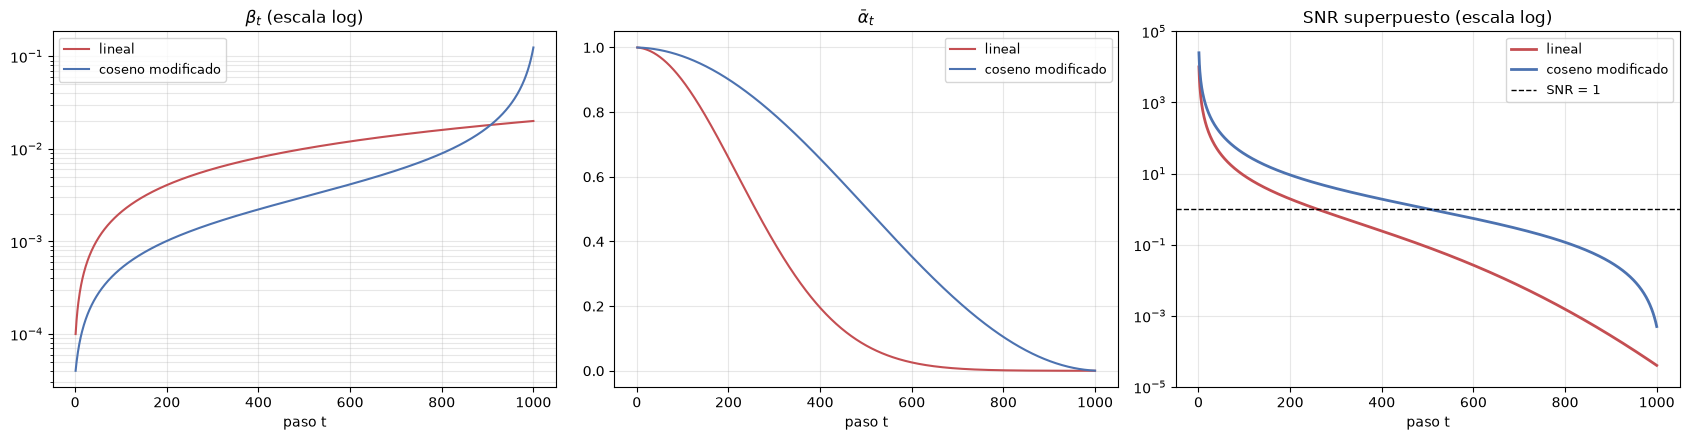

In [17]:
fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))

axes[0].plot(steps, betas, color="#C44E52", label="lineal")
axes[0].plot(steps, betas_cos, color="#4C72B0", label="coseno modificado")
axes[0].set_yscale("log")
axes[0].set_title(r"$\beta_t$ (escala log)")

axes[1].plot(steps, alpha_bars, color="#C44E52", label="lineal")
axes[1].plot(steps, alpha_bars_cos, color="#4C72B0", label="coseno modificado")
axes[1].set_title(r"$\bar\alpha_t$")

axes[2].semilogy(steps, snr_linear, color="#C44E52", linewidth=2, label="lineal")
axes[2].semilogy(steps, snr_cos, color="#4C72B0", linewidth=2, label="coseno modificado")
axes[2].axhline(1, color="black", linestyle="--", linewidth=1, label="SNR = 1")
axes[2].set_ylim(1e-5, 1e5)
axes[2].set_title("SNR superpuesto (escala log)")

for ax in axes:
    ax.set_xlabel("paso t")
    ax.grid(alpha=0.3, which="both")
    ax.legend(fontsize=9)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "lineal_vs_coseno.png", dpi=180, bbox_inches="tight")
plt.show()

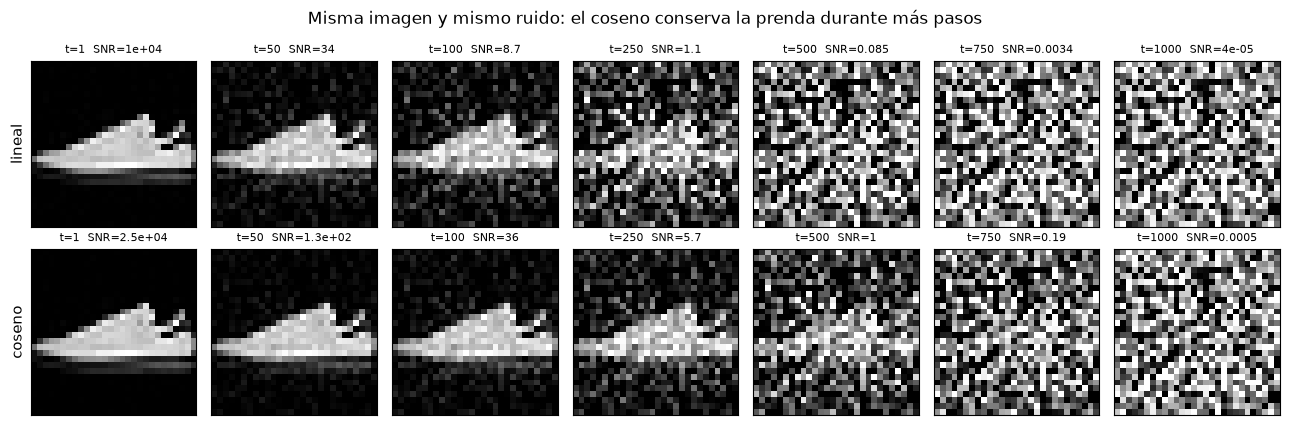

In [18]:
# El mismo Sneaker y el mismo ruido con los dos calendarios.
fig, axes = plt.subplots(2, len(T_GRID), figsize=(13, 4.4))
for row, (name, a_bars) in enumerate([("lineal", alpha_bars), ("coseno", alpha_bars_cos)]):
    for col, t in enumerate(T_GRID):
        x_t, _ = q_sample(x0_sneaker, t, a_bars, noise=eps_sneaker)
        ax = axes[row, col]
        ax.imshow(x_t.squeeze(), cmap="gray", vmin=-1, vmax=1)
        ax.set_xticks([])
        ax.set_yticks([])
        ax.set_title(f"t={t}  SNR={snr(a_bars)[t-1]:.2g}", fontsize=8)
        if col == 0:
            ax.set_ylabel(name, fontsize=11)
fig.suptitle("Misma imagen y mismo ruido: el coseno conserva la prenda durante más pasos")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "degradacion_lineal_vs_coseno.png", dpi=180, bbox_inches="tight")
plt.show()

El ángulo que encontró la bisección es $\theta_{\max}=1.5484$ rad, apenas un 1.4 % menor que $\pi/2=1.5708$. Con eso el calendario termina en $\bar\alpha_T=5.0\times10^{-4}$, que **cumple $\bar\alpha_T<0.001$**. El lineal termina en $\bar\alpha_T=4.0\times10^{-5}$, que también lo cumple. El coseno deja un poco más de señal residual al final, pero sigue siendo una mezcla con más de 99.95 % de ruido. El $\beta_t$ más grande es $0.124$ en el último paso, así que no necesitamos ningún recorte.

La diferencia está en cómo se reparten los pasos. En la gráfica de $\beta_t$, el coseno agrega muy poco ruido durante la mayor parte del calendario y concentra los $\beta_t$ grandes en los últimos ~100 pasos. Por eso su $\bar\alpha_t$ baja casi en línea recta por el centro en vez de desplomarse al principio: en $t=500$ el lineal ya solo conserva el 7.9 % de la imagen, mientras que el coseno todavía conserva el 50.5 %. En el SNR superpuesto, el coseno cruza $\text{SNR}=1$ alrededor de $t=500$ en lugar de $t=260$, y se mantiene entre $10^{-2}$ y $10^{2}$ durante casi todo el recorrido. Las miniaturas lo confirman: con el mismo ruido, el Sneaker del coseno se reconoce todavía en $t=500$, que en el lineal ya es ruido puro. En la Task 2.5b contamos exactamente cuántos pasos útiles gana cada calendario.

## 9. Task 2.5a - $\bar\alpha_T$ del calendario lineal a mano

**Paso 1: convertir el producto en una suma.** Tomando logaritmo,

$$\bar\alpha_T=\prod_{t=1}^{T}(1-\beta_t)\quad\Longrightarrow\quad \ln\bar\alpha_T=\sum_{t=1}^{T}\ln(1-\beta_t).$$

**Paso 2: aproximar cada término.** Por Taylor, $\ln(1-\beta)=-\beta-\tfrac{\beta^2}{2}-\tfrac{\beta^3}{3}-\dots$ Como todos los $\beta_t\le0.02$, el primer término domina:

$$\ln\bar\alpha_T\approx-\sum_{t=1}^{T}\beta_t.$$

**Paso 3: la suma aritmética.** Los $\beta_t$ están igualmente espaciados, así que su suma es el número de términos por el promedio del primero y el último:

$$\sum_{t=1}^{T}\beta_t=\frac{T(\beta_1+\beta_T)}{2}=\frac{1000\,(0.0001+0.02)}{2}=1000\times0.01005=10.05.$$

**Paso 4: primera aproximación.**

$$\bar\alpha_T\approx e^{-10.05}=e^{-10}\cdot e^{-0.05}\approx4.540\times10^{-5}\times0.9512\approx4.32\times10^{-5}.$$

**Paso 5: corrección de segundo orden.** El término que despreciamos es $-\tfrac12\sum\beta_t^2$. Para valores igualmente espaciados, $\sum\beta_t^2\approx T\left(\bar\beta^2+\tfrac{(\beta_T-\beta_1)^2}{12}\right)$, donde $\bar\beta=0.01005$ es el promedio:

$$\sum_{t=1}^{T}\beta_t^2\approx1000\left(0.01005^2+\frac{0.0199^2}{12}\right)=1000\,(1.010\times10^{-4}+3.300\times10^{-5})\approx0.1340.$$

Entonces

$$\bar\alpha_T\approx e^{-10.05-0.0670}=4.32\times10^{-5}\times e^{-0.067}\approx4.32\times10^{-5}\times0.9352\approx4.04\times10^{-5}.$$

La primera aproximación sobrestima $\bar\alpha_T$ porque $\ln(1-\beta)<-\beta$: cada factor real quita un poco más que $e^{-\beta}$, y en mil pasos esa diferencia se acumula.

In [19]:
beta_1, beta_T = 1e-4, 0.02
beta_mean = (beta_1 + beta_T) / 2

sum_beta_hand = T * beta_mean
sum_beta2_hand = T * (beta_mean ** 2 + (beta_T - beta_1) ** 2 / 12)

approx_1 = math.exp(-sum_beta_hand)
approx_2 = math.exp(-sum_beta_hand - sum_beta2_hand / 2)
exact = alpha_bars[-1].item()

print(f"suma de beta:   a mano = {sum_beta_hand:.5f} | código = {betas.sum():.5f}")
print(f"suma de beta^2: a mano = {sum_beta2_hand:.5f} | código = {(betas ** 2).sum():.5f}")
print()
print(f"{'método':<44} | {'alpha_bar_T':>12} | {'error relativo':>14}")
print("-" * 76)
for name, value in [
    ("1er orden: exp(-suma beta)", approx_1),
    ("2do orden: exp(-suma beta - suma beta^2/2)", approx_2),
    ("código: torch.cumprod", exact),
]:
    print(f"{name:<44} | {value:12.4e} | {abs(value - exact) / exact:13.3%}")

suma de beta:   a mano = 10.05000 | código = 10.05000
suma de beta^2: a mano = 0.13400 | código = 0.13407

método                                       |  alpha_bar_T | error relativo
----------------------------------------------------------------------------
1er orden: exp(-suma beta)                   |   4.3186e-05 |        7.006%
2do orden: exp(-suma beta - suma beta^2/2)   |   4.0387e-05 |        0.071%
código: torch.cumprod                        |   4.0358e-05 |        0.000%


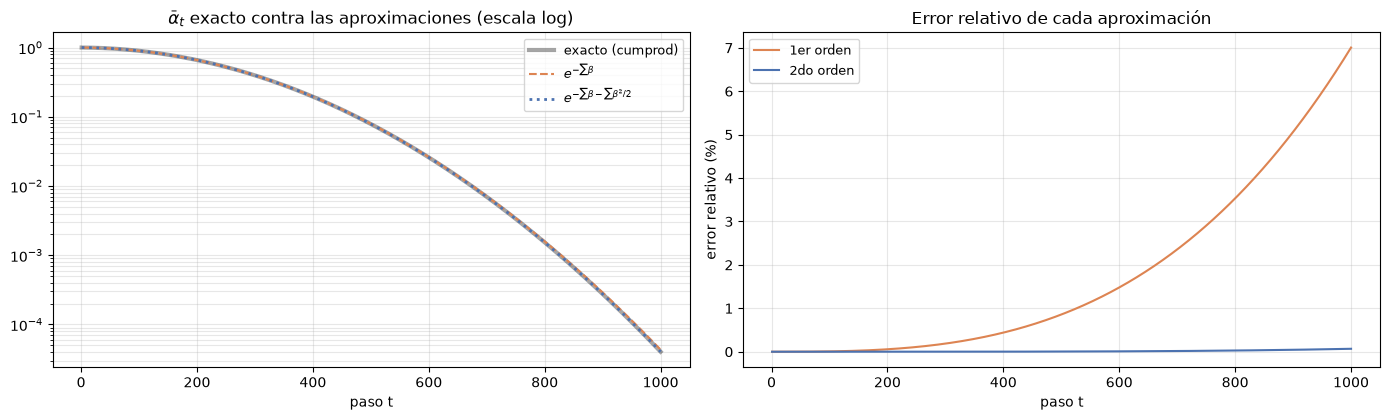

In [20]:
# Las mismas aproximaciones aplicadas a cada t, no solo a T.
cum_b1 = torch.cumsum(betas, dim=0)
cum_b2 = torch.cumsum(betas ** 2, dim=0)
approx_1_t = torch.exp(-cum_b1)
approx_2_t = torch.exp(-cum_b1 - cum_b2 / 2)

fig, axes = plt.subplots(1, 2, figsize=(14, 4.3))
axes[0].semilogy(steps, alpha_bars, color="black", linewidth=3, alpha=0.35, label="exacto (cumprod)")
axes[0].semilogy(steps, approx_1_t, color="#DD8452", linestyle="--", label=r"$e^{-\sum\beta}$")
axes[0].semilogy(steps, approx_2_t, color="#4C72B0", linestyle=":", linewidth=2, label=r"$e^{-\sum\beta-\sum\beta^2/2}$")
axes[0].set_title(r"$\bar\alpha_t$ exacto contra las aproximaciones (escala log)")
axes[0].legend(fontsize=9)

axes[1].plot(steps, 100 * (approx_1_t - alpha_bars) / alpha_bars, color="#DD8452", label="1er orden")
axes[1].plot(steps, 100 * (approx_2_t - alpha_bars) / alpha_bars, color="#4C72B0", label="2do orden")
axes[1].set_title("Error relativo de cada aproximación")
axes[1].set_ylabel("error relativo (%)")
axes[1].legend(fontsize=9)

for ax in axes:
    ax.set_xlabel("paso t")
    ax.grid(alpha=0.3, which="both")
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "aproximacion_alpha_bar.png", dpi=180, bbox_inches="tight")
plt.show()

| Método | $\bar\alpha_T$ | Error relativo |
|---|---|---|
| A mano, 1er orden: $e^{-\sum\beta_t}$ | $4.32\times10^{-5}$ | 7.0 % |
| A mano, 2do orden: $e^{-\sum\beta_t-\frac12\sum\beta_t^2}$ | $4.04\times10^{-5}$ | 0.07 % |
| Código (`torch.cumprod`) | $4.04\times10^{-5}$ | referencia |

Las dos sumas a mano coinciden con las del código: $\sum\beta_t=10.05$ exacto y $\sum\beta_t^2=0.1340$ contra $0.13407$. Con solo la suma aritmética ya acertamos el orden de magnitud ($4.3\times10^{-5}$) con un error de 7 %, y al agregar la corrección cuadrática el error baja a 0.07 %.

La figura muestra que las tres curvas son indistinguibles a simple vista en escala log, pero el error relativo de primer orden crece con $t$: cada paso aporta un error de aproximadamente $\beta_t^2/2$ en el logaritmo, y esos errores se suman. Como los $\beta_t$ grandes están al final del calendario lineal, el error aparece sobre todo después de $t\approx500$. La corrección de segundo orden elimina casi todo ese error en todo el recorrido.

## 10. Task 2.5b - ¿Cuántos pasos son útiles?

Durante el entrenamiento, la red recibe $x_t$ con un $t$ elegido al azar y debe predecir el ruido. Si el SNR es muy alto ($>100$), $x_t$ es casi la imagen limpia y predecir el ruido es trivial, porque basta con ver qué se aparta de una imagen nítida. Si el SNR es muy bajo ($<0.01$), $x_t$ es casi ruido puro y la mejor predicción posible es "el ruido es $x_t$", sin aprender nada de la imagen. Los pasos donde la red realmente aprende algo son los intermedios:

$$0.01<\text{SNR}(t)<100.$$

Contamos cuántos de los 1000 pasos de cada calendario caen en esa franja. Como todos los pasos se muestrean con la misma probabilidad, la fracción de pasos útiles es la fracción del entrenamiento que se aprovecha.

In [21]:
SNR_LOW, SNR_HIGH = 0.01, 100

zones = {}
for name, s in [("lineal", snr_linear), ("coseno", snr_cos)]:
    useful = (s > SNR_LOW) & (s < SNR_HIGH)
    useful_steps = torch.nonzero(useful).flatten() + 1
    zones[name] = {
        "muy limpio (SNR > 100)": int((s >= SNR_HIGH).sum()),
        "útil (0.01 < SNR < 100)": int(useful.sum()),
        "casi ruido (SNR < 0.01)": int((s <= SNR_LOW).sum()),
    }
    print(f"{name}: {zones[name]['útil (0.01 < SNR < 100)']} pasos útiles, "
          f"de t = {useful_steps[0].item()} a t = {useful_steps[-1].item()}")
    for zone, count in zones[name].items():
        print(f"    {zone:<26}: {count:4d} pasos ({count / T:.1%})")

gain = zones["coseno"]["útil (0.01 < SNR < 100)"] - zones["lineal"]["útil (0.01 < SNR < 100)"]
print(f"\nEl coseno gana {gain} pasos útiles "
      f"({gain / zones['lineal']['útil (0.01 < SNR < 100)']:.1%} más que el lineal).")

lineal: 647 pasos útiles, de t = 28 a t = 674
    muy limpio (SNR > 100)    :   27 pasos (2.7%)
    útil (0.01 < SNR < 100)   :  647 pasos (64.7%)
    casi ruido (SNR < 0.01)   :  326 pasos (32.6%)
coseno: 892 pasos útiles, de t = 58 a t = 949
    muy limpio (SNR > 100)    :   57 pasos (5.7%)
    útil (0.01 < SNR < 100)   :  892 pasos (89.2%)
    casi ruido (SNR < 0.01)   :   51 pasos (5.1%)

El coseno gana 245 pasos útiles (37.9% más que el lineal).


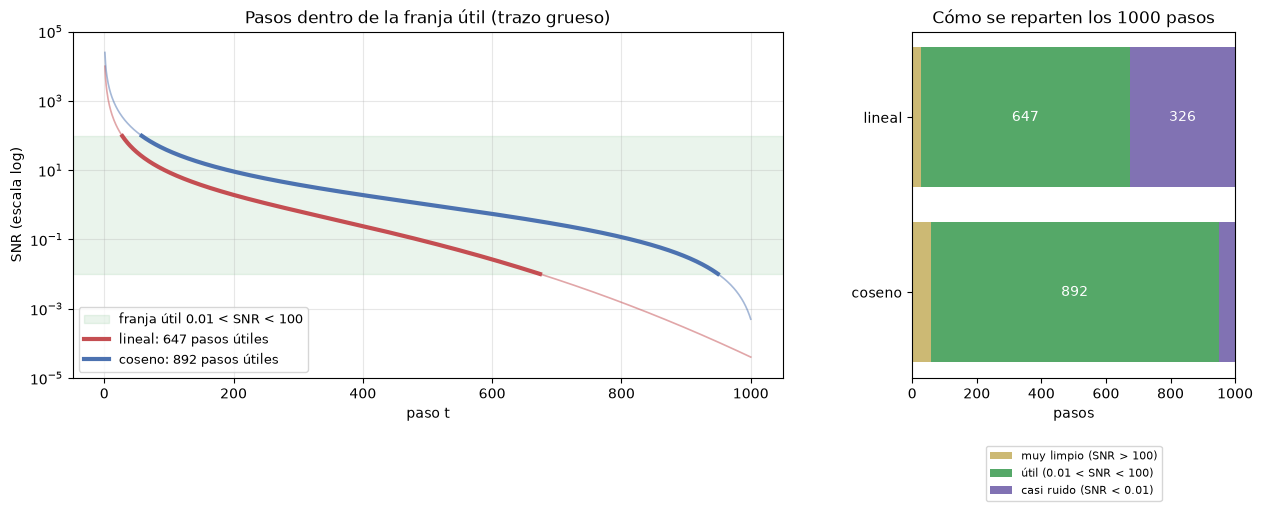

In [22]:
fig = plt.figure(figsize=(15, 4.5))
grid = fig.add_gridspec(1, 2, width_ratios=[2.2, 1], wspace=0.25)

ax = fig.add_subplot(grid[0])
ax.axhspan(SNR_LOW, SNR_HIGH, color="#55A868", alpha=0.12, label="franja útil 0.01 < SNR < 100")
for name, s, color in [("lineal", snr_linear, "#C44E52"), ("coseno", snr_cos, "#4C72B0")]:
    useful = (s > SNR_LOW) & (s < SNR_HIGH)
    ax.semilogy(steps, s, color=color, linewidth=1.2, alpha=0.5)
    ax.semilogy(steps[useful], s[useful], color=color, linewidth=3,
                label=f"{name}: {int(useful.sum())} pasos útiles")
ax.set_ylim(1e-5, 1e5)
ax.set_xlabel("paso t")
ax.set_ylabel("SNR (escala log)")
ax.set_title("Pasos dentro de la franja útil (trazo grueso)")
ax.legend(fontsize=9, loc="lower left")
ax.grid(alpha=0.3, which="both")

ax = fig.add_subplot(grid[1])
zone_colors = ["#CCB974", "#55A868", "#8172B3"]
names = list(zones)
left = torch.zeros(len(names))
for zone, color in zip(zones["lineal"], zone_colors):
    counts = torch.tensor([zones[n][zone] for n in names], dtype=torch.float64)
    bars = ax.barh(names, counts, left=left, color=color, label=zone)
    for bar, count in zip(bars, counts):
        if count > 100:
            ax.text(bar.get_x() + bar.get_width() / 2, bar.get_y() + bar.get_height() / 2,
                    f"{int(count)}", ha="center", va="center", color="white", fontsize=10)
    left += counts
ax.set_xlim(0, T)
ax.set_xlabel("pasos")
ax.set_title("Cómo se reparten los 1000 pasos")
ax.legend(fontsize=8, loc="upper center", bbox_to_anchor=(0.5, -0.18), ncol=1)
ax.invert_yaxis()

plt.savefig(OUTPUT_DIR / "pasos_utiles.png", dpi=180, bbox_inches="tight")
plt.show()

| Calendario | SNR > 100 | **0.01 < SNR < 100** | SNR < 0.01 | Franja útil |
|---|---|---|---|---|
| Lineal | 27 | **647** (64.7 %) | 326 | $t=28$ a $674$ |
| Coseno modificado | 57 | **892** (89.2 %) | 51 | $t=58$ a $949$ |

**El coseno modificado es más eficiente:** tiene 245 pasos útiles más que el lineal, un 37.9 % más. La diferencia viene casi por completo del final del calendario. El lineal gasta 326 pasos (un tercio del total) con SNR por debajo de 0.01, donde $x_t$ ya es ruido puro; coincide con lo que vimos en la Task 2.3c, porque $\text{SNR}<0.01$ equivale a $\bar\alpha_t<0.0099$. El coseno reduce esa zona a solo 51 pasos.

El coseno sí cede un poco al principio: tiene 57 pasos con SNR mayor que 100, contra 27 del lineal, porque agrega el ruido más despacio en los primeros pasos. Pero ese costo es de 30 pasos frente a los 275 que recupera al final, así que el balance es claramente favorable. En la gráfica de la izquierda se ve por qué: la curva azul recorre la franja verde de forma pareja durante casi todo el calendario, mientras que la roja la atraviesa rápido y sale de ella en $t=674$.

## 11. Task 2.5c - La varianza de $x_t$

**Demostración.** Partimos de la forma cerrada $x_t=\sqrt{\bar\alpha_t}\,x_0+\sqrt{1-\bar\alpha_t}\,\varepsilon$, donde $\varepsilon\sim\mathcal N(0,I)$ se genera **independiente** de la imagen $x_0$. Para dos variables aleatorias $X$, $Y$ y constantes $a$, $b$,

$$\operatorname{Var}(aX+bY)=a^2\operatorname{Var}(X)+b^2\operatorname{Var}(Y)+2ab\operatorname{Cov}(X,Y).$$

Con $a=\sqrt{\bar\alpha_t}$, $b=\sqrt{1-\bar\alpha_t}$, $X=x_0$ y $Y=\varepsilon$:

- $a^2=\bar\alpha_t$ y $b^2=1-\bar\alpha_t$;
- $\operatorname{Var}(\varepsilon)=1$, porque es ruido normal estándar;
- $\operatorname{Cov}(x_0,\varepsilon)=0$, porque son independientes.

Por lo tanto

$$\boxed{\operatorname{Var}(x_t)=\bar\alpha_t\operatorname{Var}(x_0)+(1-\bar\alpha_t)}.\qquad\blacksquare$$

**Qué significa.** La varianza de $x_t$ es un promedio ponderado entre la de los datos y la del ruido, con los mismos pesos $\bar\alpha_t$ y $1-\bar\alpha_t$ que suman 1. En $t=0$ vale $\operatorname{Var}(x_0)$ y, como $\bar\alpha_T\approx0$, al final vale $\approx1$, que es justo la varianza de $\mathcal N(0,I)$. Con la media pasa lo mismo: $\mathbb E[x_t]=\sqrt{\bar\alpha_t}\,\mathbb E[x_0]\to0$. Así, el final del proceso encaja con la distribución desde la que arranca el muestreo.

Para comprobarla tomamos 10,000 imágenes de entrenamiento, les aplicamos `q_sample` con ruido nuevo y medimos la varianza de todos sus píxeles.

In [23]:
N_VAR = 10_000
x0_var = torch.stack([train_set[i][0] for i in range(N_VAR)])
var_x0 = x0_var.var().item()
mean_x0 = x0_var.mean().item()
print(f"{N_VAR} imágenes | Var(x_0) = {var_x0:.5f} | E[x_0] = {mean_x0:.5f}")
print()

T_VAR = [1, 250, 500, 1000]
g = torch.Generator().manual_seed(SEED)
var_rows = []
header = (f"{'calendario':>10} | {'t':>5} | {'alpha_bar_t':>11} | {'Var teórica':>11} | "
          f"{'Var empírica':>12} | {'diferencia':>10} | {'E[x_t]':>8}")
print(header)
print("-" * len(header))
for name, a_bars in [("lineal", alpha_bars), ("coseno", alpha_bars_cos)]:
    for t in T_VAR:
        x_t, _ = q_sample(x0_var, torch.full((N_VAR,), t), a_bars, generator=g)
        a_bar = a_bars[t - 1].item()
        var_theory = a_bar * var_x0 + (1 - a_bar)
        var_emp = x_t.var().item()
        var_rows.append((name, t, var_theory, var_emp))
        print(f"{name:>10} | {t:5d} | {a_bar:11.6f} | {var_theory:11.5f} | {var_emp:12.5f} | "
              f"{var_emp - var_theory:+10.5f} | {x_t.mean().item():+8.4f}")

10000 imágenes | Var(x_0) = 0.50131 | E[x_0] = -0.42738

calendario |     t | alpha_bar_t | Var teórica | Var empírica | diferencia |   E[x_t]
-------------------------------------------------------------------------------------
    lineal |     1 |    0.999900 |     0.50136 |      0.50136 |   -0.00000 |  -0.4274


    lineal |   250 |    0.524085 |     0.73865 |      0.73852 |   -0.00012 |  -0.3095
    lineal |   500 |    0.078587 |     0.96081 |      0.96077 |   -0.00004 |  -0.1198


    lineal |  1000 |    0.000040 |     0.99998 |      1.00029 |   +0.00031 |  -0.0030
    coseno |     1 |    0.999960 |     0.50133 |      0.50133 |   -0.00000 |  -0.4274


    coseno |   250 |    0.851108 |     0.57557 |      0.57553 |   -0.00004 |  -0.3942
    coseno |   500 |    0.505112 |     0.74811 |      0.74826 |   +0.00015 |  -0.3041


    coseno |  1000 |    0.000500 |     0.99975 |      0.99940 |   -0.00035 |  -0.0102


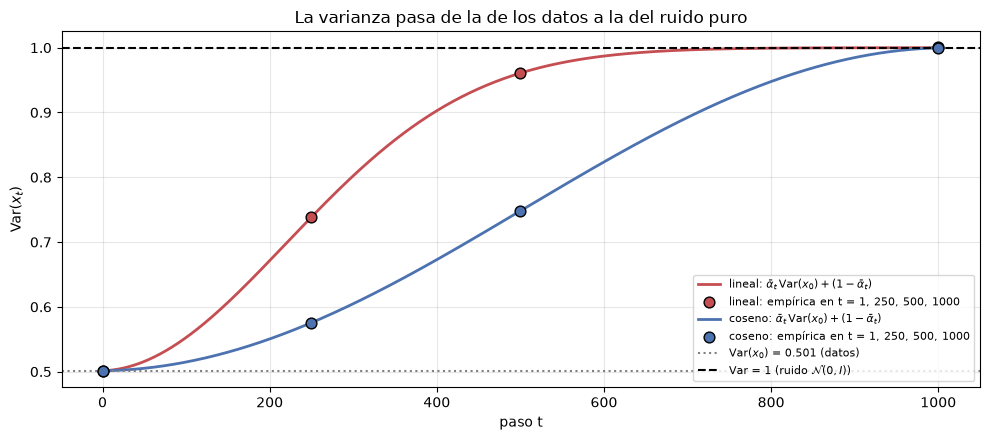

In [24]:
fig, ax = plt.subplots(figsize=(10, 4.5))
for name, a_bars, color in [("lineal", alpha_bars, "#C44E52"), ("coseno", alpha_bars_cos, "#4C72B0")]:
    ax.plot(steps, a_bars * var_x0 + (1 - a_bars), color=color, linewidth=2,
            label=rf"{name}: $\bar\alpha_t\,\mathrm{{Var}}(x_0)+(1-\bar\alpha_t)$")
    points = [(t, v) for n, t, _, v in var_rows if n == name]
    ax.scatter(*zip(*points), color=color, edgecolor="black", s=60, zorder=3,
               label=f"{name}: empírica en t = 1, 250, 500, 1000")
ax.axhline(var_x0, color="gray", linestyle=":", label=rf"Var$(x_0)$ = {var_x0:.3f} (datos)")
ax.axhline(1, color="black", linestyle="--", label=r"Var = 1 (ruido $\mathcal{N}(0, I)$)")
ax.set_xlabel("paso t")
ax.set_ylabel(r"Var$(x_t)$")
ax.set_title("La varianza pasa de la de los datos a la del ruido puro")
ax.legend(fontsize=8, loc="lower right")
ax.grid(alpha=0.3)
plt.tight_layout()
plt.savefig(OUTPUT_DIR / "varianza_xt.png", dpi=180, bbox_inches="tight")
plt.show()

Con 10,000 imágenes medimos $\operatorname{Var}(x_0)=0.5013$. La comprobación en los cuatro pasos pedidos, con el calendario lineal:

| $t$ | $\bar\alpha_t$ | Var teórica | Var empírica | Diferencia |
|---|---|---|---|---|
| 1 | 0.99990 | 0.50136 | 0.50136 | 0.00000 |
| 250 | 0.52409 | 0.73865 | 0.73852 | −0.00012 |
| 500 | 0.07859 | 0.96081 | 0.96077 | −0.00004 |
| 1000 | 0.00004 | 0.99998 | 1.00029 | +0.00031 |

Todas las diferencias son menores que $4\times10^{-4}$, del tamaño esperado por usar una muestra finita. Con el coseno modificado ocurre lo mismo (diferencias de $3.5\times10^{-4}$ como máximo), solo que la varianza sube más despacio: en $t=500$ vale $0.748$ en lugar de $0.961$, otra forma de ver que conserva la imagen por más tiempo.

En $t=1000$ los dos calendarios llegan a $\operatorname{Var}(x_T)\approx1$ y $\mathbb E[x_T]\approx0$ ($-0.003$ en el lineal y $-0.010$ en el coseno, que deja un poco más de señal). Es decir, $x_T$ tiene la media y la varianza de $\mathcal N(0,I)$: el final del proceso forward encaja con el ruido puro desde el que el modelo empezará a generar en la Task 3.

## Resumen de la Task 2

- Construimos el calendario lineal ($\beta_t$ de $10^{-4}$ a $0.02$) y la forma cerrada `q_sample`, que reutilizaremos en la Task 3.
- Verificamos el atajo con 5,000 copias ensuciadas 300 veces: la varianza promedio quedó a 1.13 errores estándar de la teórica y el peor píxel de la media a 4.06, lo que es compatible con ruido de muestreo.
- Con el calendario lineal el SNR baja de 1 en $t=260$ y $\bar\alpha_t$ baja de 0.01 en $t=674$, así que casi un tercio de los pasos ocurre con ruido prácticamente puro.
- Nuestro coseno modificado termina en $\bar\alpha_T=5\times10^{-4}<0.001$ sin necesidad de recortar $\beta_t$, y tiene 892 pasos útiles ($0.01<\text{SNR}<100$) contra 647 del lineal.
- La aproximación $\bar\alpha_T\approx e^{-\sum\beta_t}=e^{-10.05}$ acierta con un error de 7 %, que baja a 0.07 % con la corrección de segundo orden.
- Demostramos que $\operatorname{Var}(x_t)=\bar\alpha_t\operatorname{Var}(x_0)+(1-\bar\alpha_t)$ y la comprobamos con errores menores que $4\times10^{-4}$; al final $x_T$ tiene media 0 y varianza 1, como $\mathcal N(0,I)$.